# Data Cleaning Exercise

Cleaning your data is crucial when starting a new data engineering project because it ensures the accuracy, consistency, and reliability of the dataset. Dirty data, which may include duplicates, missing values, and errors, can lead to incorrect analysis and insights, ultimately affecting the decision-making process. Data cleaning helps in identifying and rectifying these issues, providing a solid foundation for building effective data models and analytics. Additionally, clean data improves the performance of algorithms and enhances the overall efficiency of the project, leading to more trustworthy and actionable results.

Use Python, ```numpy```, ```pandas``` and/or ```matplotlib``` to analyse and clean your batch data:

## Import Libraries

In [87]:
# Import the libraries used throughout the notebook.
# numpy is used for missing-value markers, pandas for tabular data cleaning,
# and matplotlib for visualizing the cleaned dataset.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

Link to data source: ```https://en.wikipedia.org/wiki/List_of_European_Union_cities_proper_by_population_density```

In [88]:
# Load the web-scraping dependencies.
# requests downloads the Wikipedia page, BeautifulSoup parses the HTML table.
import requests
from bs4 import BeautifulSoup

# Define the source URL once so the data origin is transparent and easy to change.
wikipedia_url = "https://en.wikipedia.org/wiki/List_of_European_Union_cities_proper_by_population_density"

# Download the HTML page with a timeout so the notebook does not wait forever.
response = requests.get(
    wikipedia_url,
    headers={"User-Agent": "data-cleaning-exercise/1.0"},
    timeout=30,
)
# Stop immediately if the page could not be loaded successfully.
response.raise_for_status()

# Parse the HTML and select the Wikipedia table that contains the city data.
soup = BeautifulSoup(response.text, "html.parser")
table = soup.select_one("table.wikitable")

# Raise a clear error if Wikipedia changes the table structure.
if table is None:
    raise ValueError("No Wikipedia table with class 'wikitable' was found.")

# Extract all rows as plain text so links and HTML markup do not remain in the data.
rows = []
for table_row in table.select("tr"):
    cells = [cell.get_text(" ", strip=True) for cell in table_row.select("th, td")]
    if cells:
        rows.append(cells)

# Build the raw DataFrame. The first scraped row contains the column names.
city_density_raw = pd.DataFrame(rows[1:], columns=rows[0])

# Show a quick load check to verify that scraping returned usable data.
print(f"Loaded {city_density_raw.shape[0]} rows and {city_density_raw.shape[1]} columns from Wikipedia.")
city_density_raw.head()

Loaded 69 rows and 8 columns from Wikipedia.


,Rank,City,Population,Area (km 2 ),Area (sq. miles),Density (/km 2 ),Density (/sq. mile),Country
0,1,Levallois-Perret,"66,082",2.41,0.93,"27,420","71,056",France
1,2,Emperador,692,0.03,0.01,"23,067","69,200",Spain
2,3,L'Hospitalet de Llobregat,"264,923",12.4,4.8,"21,364","55,599",Spain
3,4,Paris,"2,203,817",105.4,40.5,"20,909","54,415",France
4,5,Mislata,"43,278",2.10,0.81,"20,608","53,430",Spain


## Understand the Data

View the first few rows, get summary statistics and check data types

In [89]:
# Inspect the basic structure of the raw data before cleaning.
# This tells us how many rows and columns were loaded from Wikipedia.
print("Shape:")
print(city_density_raw.shape)

# Check the column names so later cleaning steps can refer to the right fields.
print("\nColumns:")
print(city_density_raw.columns.tolist())

# Display sample rows to understand the table layout and spot obvious issues.
print("\nFirst rows:")
display(city_density_raw.head())

# Review data types. Scraped HTML values usually arrive as text and need conversion.
print("\nData types:")
display(city_density_raw.dtypes)

# Count missing values before cleaning so we know which columns need attention.
print("\nMissing values per column:")
display(city_density_raw.isna().sum())

# Summarize all columns to identify duplicates, repeated values and unusual patterns.
print("\nSummary statistics for text columns:")
display(city_density_raw.describe(include="all"))

Shape:
(69, 8)

Columns:
['Rank', 'City', 'Population', 'Area (km 2 )', 'Area (sq. miles)', 'Density (/km 2 )', 'Density (/sq. mile)', 'Country']

First rows:


,Rank,City,Population,Area (km 2 ),Area (sq. miles),Density (/km 2 ),Density (/sq. mile),Country
0,1,Levallois-Perret,"66,082",2.41,0.93,"27,420","71,056",France
1,2,Emperador,692,0.03,0.01,"23,067","69,200",Spain
2,3,L'Hospitalet de Llobregat,"264,923",12.4,4.8,"21,364","55,599",Spain
3,4,Paris,"2,203,817",105.4,40.5,"20,909","54,415",France
4,5,Mislata,"43,278",2.10,0.81,"20,608","53,430",Spain



Data types:


Rank                   object
City                   object
Population             object
Area (km 2 )           object
Area (sq. miles)       object
Density (/km 2 )       object
Density (/sq. mile)    object
Country                object
dtype: object


Missing values per column:


Rank                   0
City                   0
Population             0
Area (km 2 )           0
Area (sq. miles)       0
Density (/km 2 )       0
Density (/sq. mile)    0
Country                0
dtype: int64


Summary statistics for text columns:


,Rank,City,Population,Area (km 2 ),Area (sq. miles),Density (/km 2 ),Density (/sq. mile),Country
count,69,69,69,69,69,69,69,69
unique,69,68,69,69,68,69,69,18
top,1,Dublin,"66,082",2.41,3.9,"27,420","71,056",Spain
freq,1,2,1,1,2,1,1,12


## Handle Missing Data

Identify missing values and fill or drop missing values

In [90]:
# Start the cleaning process on a copy so the original scraped data stays available
# for comparison and debugging.
city_density_clean = city_density_raw.copy()

# Standardize common missing-value markers to np.nan.
# This makes pandas missing-value functions work consistently across all columns.
city_density_clean = city_density_clean.replace(r"^\s*$", np.nan, regex=True)
city_density_clean = city_density_clean.replace(["\u2014", "-", "n/a", "N/A", "None"], np.nan)

# Calculate the number and percentage of missing values per column.
# The table documents whether missing data is a real quality issue in this source.
missing_values = city_density_clean.isna().sum().to_frame("missing_values")
missing_values["missing_percentage"] = (
    missing_values["missing_values"] / len(city_density_clean) * 100
).round(2)

display(missing_values)

# Keep only rows that have the essential fields needed for the later analysis.
# Rows without city, country, population, area or density cannot support the project question.
essential_columns = ["City", "Country", "Population", "Area (km 2 )", "Density (/km 2 )"]
rows_before = len(city_density_clean)
city_density_clean = city_density_clean.dropna(subset=essential_columns).reset_index(drop=True)
rows_after = len(city_density_clean)

print(f"Removed {rows_before - rows_after} rows with missing essential values.")

,missing_values,missing_percentage
Rank,0,0.0
City,0,0.0
Population,0,0.0
Area (km 2 ),0,0.0
Area (sq. miles),0,0.0
Density (/km 2 ),0,0.0
Density (/sq. mile),0,0.0
Country,0,0.0


Removed 0 rows with missing essential values.


## Handle Duplicates

Identify duplicates and remove them

In [91]:
# Check for duplicate records before analysis.
# Exact duplicates indicate repeated rows; City/Country duplicates indicate repeated entities.
exact_duplicate_count = city_density_clean.duplicated().sum()
city_country_duplicate_count = city_density_clean.duplicated(subset=["City", "Country"]).sum()

print(f"Exact duplicate rows: {exact_duplicate_count}")
print(f"Duplicate City/Country combinations: {city_country_duplicate_count}")
print("Duplicate handling: rows with the same City and Country are merged by averaging population and area values; density and rank are recalculated afterwards.")

# If duplicated city-country pairs exist, display them so the removal decision is transparent.
if city_country_duplicate_count > 0:
    display(city_density_clean[city_density_clean.duplicated(subset=["City", "Country"], keep=False)])

# Combine duplicate City/Country rows instead of discarding one row.
# Dublin appears twice in the Wikipedia table. For this exercise, both rows are
# treated as measurements for the same city entity, so their base measurements
# are averaged into one analysis row instead of losing either source row.
base_measure_columns = ["Population", "Area (km 2 )", "Area (sq. miles)"]
numeric_columns_for_duplicate_handling = [
    "Rank",
    *base_measure_columns,
    "Density (/km 2 )",
    "Density (/sq. mile)",
]

# Convert numeric-looking text values temporarily, because scraped values can contain
# commas or Wikipedia footnotes such as '[ 4 ]'.
duplicates_for_aggregation = city_density_clean.copy()
for column in numeric_columns_for_duplicate_handling:
    duplicates_for_aggregation[column] = pd.to_numeric(
        duplicates_for_aggregation[column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.extract(r"([-+]?\d*\.?\d+)")[0],
        errors="coerce",
    )

# Group by the duplicate key and average only base measurements.
# Rank is an ordering field, not a measured city attribute, so it is not averaged.
city_density_clean = (
    duplicates_for_aggregation
    .groupby(["City", "Country"], as_index=False, sort=False)[base_measure_columns]
    .mean()
)

# Recalculate derived density columns from the averaged base measurements.
# This is more consistent than averaging old density values directly.
city_density_clean["Density (/km 2 )"] = (
    city_density_clean["Population"] / city_density_clean["Area (km 2 )"]
)
city_density_clean["Density (/sq. mile)"] = (
    city_density_clean["Population"] / city_density_clean["Area (sq. miles)"]
)

# Recreate the rank from the recalculated density so it remains a true ordering value.
city_density_clean["Rank"] = city_density_clean["Density (/km 2 )"].rank(
    method="first",
    ascending=False,
)

# Restore the original column order so the following notebook cells can continue unchanged.
city_density_clean = city_density_clean[
    ["Rank", "City", "Population", "Area (km 2 )", "Area (sq. miles)", "Density (/km 2 )", "Density (/sq. mile)", "Country"]
]
city_density_clean = city_density_clean.reset_index(drop=True)

print(f"Rows after duplicate handling: {len(city_density_clean)}")



Exact duplicate rows: 0
Duplicate City/Country combinations: 1
Duplicate handling: rows with the same City and Country are merged by averaging population and area values; density and rank are recalculated afterwards.


,Rank,City,Population,Area (km 2 ),Area (sq. miles),Density (/km 2 ),Density (/sq. mile),Country
42,43,Dublin,"553,165",114.99,44.40,"4,811","12,460",Ireland
45,46,Dublin,"554,554",117.80,45.48,"4,708","12,193",Ireland


Rows after duplicate handling: 68


## Handle Outliers

Identify outliers and remove or corret them

In [92]:
# Helper function for converting scraped text into numbers.
# Wikipedia values can contain commas, spaces or footnote text, so we extract the numeric part.
def parse_number(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.extract(r"([-+]?\d*\.?\d+)")[0],
        errors="coerce",
    )


# Create temporary numeric columns for validation and outlier checks.
# This keeps the original column names unchanged until the data-type cleaning step.
outlier_check = pd.DataFrame(
    {
        "population": parse_number(city_density_clean["Population"]),
        "area_km2": parse_number(city_density_clean["Area (km 2 )"]),
        "density_per_km2": parse_number(city_density_clean["Density (/km 2 )"]),
    }
)

# Identify impossible values such as zero or negative population, area or density.
# These would be data errors for this dataset and should not be used in analysis.
invalid_rows = city_density_clean[
    (outlier_check["population"] <= 0)
    | (outlier_check["area_km2"] <= 0)
    | (outlier_check["density_per_km2"] <= 0)
]

print(f"Rows with impossible numeric values: {len(invalid_rows)}")
if len(invalid_rows) > 0:
    display(invalid_rows)

# Remove impossible rows and keep the temporary validation table aligned with the cleaned data.
city_density_clean = city_density_clean.drop(index=invalid_rows.index).reset_index(drop=True)
outlier_check = outlier_check.drop(index=invalid_rows.index).reset_index(drop=True)

# Use the IQR method to detect statistically unusual population densities.
# This flags extreme values without assuming a normal distribution.
q1 = outlier_check["density_per_km2"].quantile(0.25)
q3 = outlier_check["density_per_km2"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Store the flagged rows for inspection instead of removing them automatically.
# In this ranked dataset, very high density is expected and analytically important.
statistical_outliers = city_density_clean[
    (outlier_check["density_per_km2"] < lower_bound)
    | (outlier_check["density_per_km2"] > upper_bound)
]

print(f"Density IQR bounds: {lower_bound:.2f} to {upper_bound:.2f}")
print(f"Statistical density outliers: {len(statistical_outliers)}")

if len(statistical_outliers) > 0:
    display(statistical_outliers[["City", "Country", "Density (/km 2 )"]])

print("Outlier handling: impossible values are removed, while statistical density outliers are only flagged and kept because high density is the key signal of this ranked city dataset.")
print("Statistical density outliers are kept because high density is the main signal of this ranked Wikipedia dataset.")

Rows with impossible numeric values: 0
Density IQR bounds: -5299.37 to 19576.69
Statistical density outliers: 5


,City,Country,Density (/km 2 )
0,Levallois-Perret,France,27419.917012
1,Emperador,Spain,23066.666667
2,L'Hospitalet de Llobregat,Spain,21364.758065
3,Paris,France,20909.079696
4,Mislata,Spain,20608.571429


Outlier handling: impossible values are removed, while statistical density outliers are only flagged and kept because high density is the key signal of this ranked city dataset.
Statistical density outliers are kept because high density is the main signal of this ranked Wikipedia dataset.


## Handle Incorrect Data Types

In [93]:
# Rename columns to clean, code-friendly names.
# This avoids spaces, brackets and unit text in column references later in the notebook.
city_density_clean = city_density_clean.rename(
    columns={
        "Rank": "rank",
        "City": "city",
        "Population": "population",
        "Area (km 2 )": "area_km2",
        "Area (sq. miles)": "area_sq_miles",
        "Density (/km 2 )": "density_per_km2",
        "Density (/sq. mile)": "density_per_sq_mile",
        "Country": "country",
    }
)

# Clean text columns by using pandas string type and removing leading/trailing spaces.
text_columns = ["city", "country"]
for column in text_columns:
    city_density_clean[column] = city_density_clean[column].astype("string").str.strip()

# Remove Wikipedia footnote markers from city names, e.g. 'Berlin [ 4 ]' -> 'Berlin'.
city_density_clean["city"] = city_density_clean["city"].str.replace(r"\s*\[\s*\d+\s*\]", "", regex=True)

# List all columns that should be numeric for statistics, plotting and export.
numeric_columns = [
    "rank",
    "population",
    "area_km2",
    "area_sq_miles",
    "density_per_km2",
    "density_per_sq_mile",
]

# Convert numeric-looking text values to real numeric data types.
# This is required because scraped HTML tables are loaded as strings by default.
for column in numeric_columns:
    city_density_clean[column] = parse_number(city_density_clean[column])

# Check whether conversion introduced missing values because a value could not be parsed.
missing_after_conversion = city_density_clean[numeric_columns].isna().sum()
print("Missing numeric values after type conversion:")
display(missing_after_conversion)

# Drop rows that still have incomplete numeric values after conversion.
# Complete numeric rows are needed for reliable plots and saved output.
rows_before = len(city_density_clean)
city_density_clean = city_density_clean.dropna(subset=numeric_columns).reset_index(drop=True)
rows_after = len(city_density_clean)
print(f"Removed {rows_before - rows_after} rows with incomplete numeric values after conversion.")

# Convert count-like and ordering columns to nullable integers so they keep integer semantics.
# Rank was recalculated after duplicate aggregation, so it can be stored as an integer again.
integer_columns = ["rank", "population", "density_per_km2", "density_per_sq_mile"]
for column in integer_columns:
    city_density_clean[column] = city_density_clean[column].round().astype("Int64")

# Restore the original ranking order after filtering and reset the index for a clean table.
city_density_clean = city_density_clean.sort_values("rank").reset_index(drop=True)

# Display the final cleaned table structure and summary for validation.
display(city_density_clean.head())
display(city_density_clean.dtypes)
display(city_density_clean.describe(include="all"))

print("Data type handling: column names are standardized, text fields are cleaned, numeric values are extracted from scraped strings, incomplete numeric rows are removed, and count-like fields are converted to integer types.")


Missing numeric values after type conversion:


rank                   0
population             0
area_km2               0
area_sq_miles          0
density_per_km2        0
density_per_sq_mile    0
dtype: int64

Removed 0 rows with incomplete numeric values after conversion.


,rank,city,population,area_km2,area_sq_miles,density_per_km2,density_per_sq_mile,country
0,1,Levallois-Perret,66082,2.41,0.93,27420,71056,France
1,2,Emperador,692,0.03,0.01,23067,69200,Spain
2,3,L'Hospitalet de Llobregat,264923,12.40,4.80,21365,55192,Spain
3,4,Paris,2203817,105.40,40.50,20909,54415,France
4,5,Mislata,43278,2.10,0.81,20609,53430,Spain


rank                            Int64
city                   string[python]
population                      Int64
area_km2                      float64
area_sq_miles                 float64
density_per_km2                 Int64
density_per_sq_mile             Int64
country                string[python]
dtype: object

,rank,city,population,area_km2,area_sq_miles,density_per_km2,density_per_sq_mile,country
count,68.0,68,68.0,68.000000,68.000000,68.0,68.0,68
unique,<NA>,68,<NA>,NaN,NaN,<NA>,<NA>,18
top,<NA>,Levallois-Perret,<NA>,NaN,NaN,<NA>,<NA>,Spain
freq,<NA>,1,<NA>,NaN,NaN,<NA>,<NA>,12
mean,34.5,NaN,576412.264706,107.146993,41.398926,8323.411765,21469.352941,NaN
std,19.77372,NaN,742746.750055,160.961574,62.135192,5846.05286,15596.171944,NaN
min,1.0,NaN,692.0,0.030000,0.010000,3033.0,7855.0,NaN
25%,17.75,NaN,65422.75,7.497500,2.892500,4028.75,10434.5,NaN
50%,34.5,NaN,302089.5,48.320000,18.655000,6151.5,14789.0,NaN
75%,51.25,NaN,747399.5,131.245000,50.692500,10248.5,26630.0,NaN


Data type handling: column names are standardized, text fields are cleaned, numeric values are extracted from scraped strings, incomplete numeric rows are removed, and count-like fields are converted to integer types.


## Visualize Data

Use graphes, plots and/or diagrams to visualize the data

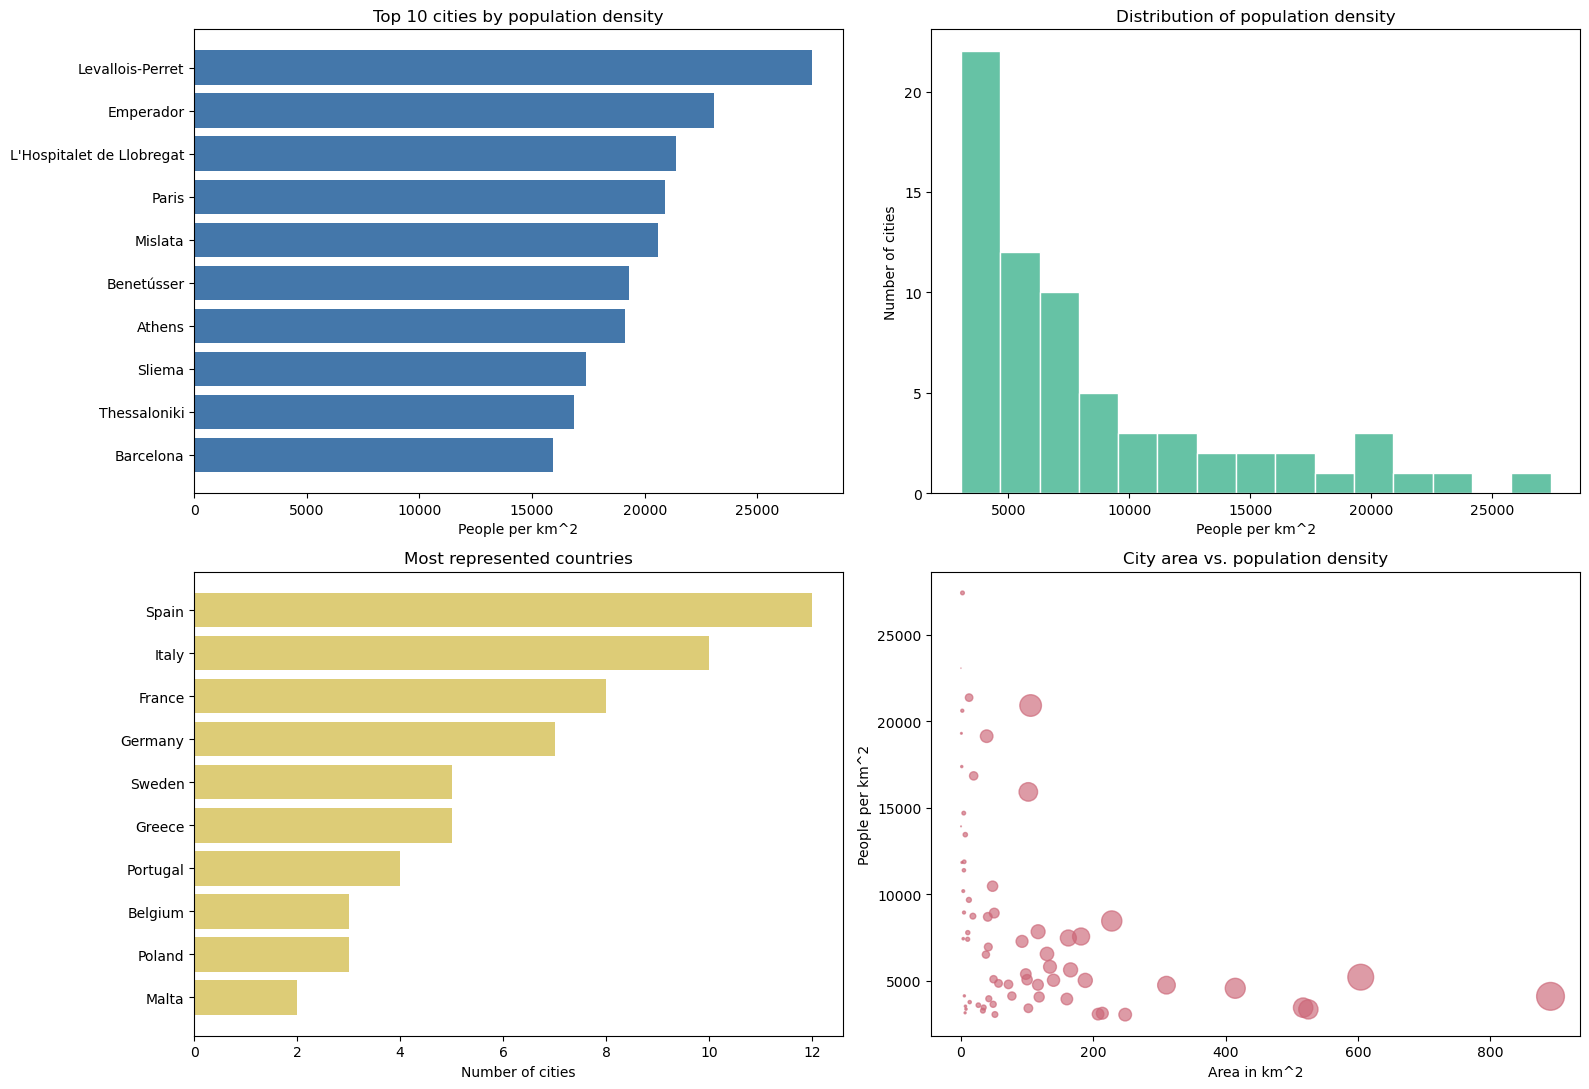

In [94]:
# Use a simple default plot style so the charts are readable in any notebook environment.
plt.style.use("default")

# Prepare the datasets used by the four visualizations.
# These views help explain rankings, distributions, country coverage and density patterns.
top_10_density = city_density_clean.nlargest(10, "density_per_km2").sort_values("density_per_km2")
country_counts = city_density_clean["country"].value_counts().head(10).sort_values()
scatter_data = city_density_clean.dropna(subset=["area_km2", "density_per_km2", "population"])
# Convert marker sizes to a NumPy array because matplotlib scatter expects numeric array-like values.
marker_sizes = (scatter_data["population"].astype(float) / scatter_data["population"].max() * 400).to_numpy()

# Create a 2x2 dashboard so the cleaned data can be inspected from multiple angles.
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Bar chart: shows which cities have the highest population density.
axes[0, 0].barh(top_10_density["city"], top_10_density["density_per_km2"], color="#4477aa")
axes[0, 0].set_title("Top 10 cities by population density")
axes[0, 0].set_xlabel("People per km^2")

# Histogram: shows how density values are distributed across all cleaned cities.
axes[0, 1].hist(city_density_clean["density_per_km2"], bins=15, color="#66c2a5", edgecolor="white")
axes[0, 1].set_title("Distribution of population density")
axes[0, 1].set_xlabel("People per km^2")
axes[0, 1].set_ylabel("Number of cities")

# Bar chart: checks which countries are most represented in the scraped table.
axes[1, 0].barh(country_counts.index, country_counts.values, color="#ddcc77")
axes[1, 0].set_title("Most represented countries")
axes[1, 0].set_xlabel("Number of cities")

# Scatterplot: compares city area and density; marker size represents population.
axes[1, 1].scatter(
    scatter_data["area_km2"].astype(float).to_numpy(),
    scatter_data["density_per_km2"].astype(float).to_numpy(),
    s=marker_sizes,
    alpha=0.65,
    color="#cc6677",
)
axes[1, 1].set_title("City area vs. population density")
axes[1, 1].set_xlabel("Area in km^2")
axes[1, 1].set_ylabel("People per km^2")

# Adjust spacing so titles and labels do not overlap, then render the plots.
plt.tight_layout()
plt.show()

## Save Cleaned Data

In [95]:
# Import pathlib for platform-independent file and folder paths.
from pathlib import Path

# Resolve the project root whether the notebook is run from the project folder
# or directly from the notebooks folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
# Create the processed-data folder if it does not exist yet.
# This keeps raw and cleaned data separated in a reproducible project structure.
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# Save the final cleaned dataset as CSV so it can be reused by later notebooks,
# Spark jobs or reporting steps without scraping Wikipedia again.
csv_path = processed_dir / "wikipedia_eu_city_density_clean.csv"
city_density_clean.to_csv(csv_path, index=False)

# Print the output path as a final confirmation for the notebook run.
print(f"Saved cleaned data to: {csv_path}")

Saved cleaned data to: /home/jovyan/work/data/processed/wikipedia_eu_city_density_clean.csv
